In [ ]:
import pandas as pd
import requests
import ssl
from requests.adapters import HTTPAdapter
from urllib3.poolmanager import PoolManager
from io import BytesIO
from io import StringIO

In [ ]:
class LegacySSLAdapter(HTTPAdapter):
    def init_poolmanager(self, connections, maxsize, block=False, **pool_kwargs):
        context = ssl.create_default_context()
        context.set_ciphers("DEFAULT@SECLEVEL=1")

        self.poolmanager = PoolManager(
            num_pools=connections,
            maxsize=maxsize,
            block=block,
            ssl_context=context,
            **pool_kwargs
        )


# Crear sesión
session = requests.Session()
session.mount("https://", LegacySSLAdapter())

In [ ]:
def cargar_csv(url):
    response = session.get(url, timeout=60)
    response.raise_for_status()

    texto = response.content.decode("utf-8-sig", errors="replace")
    lineas = texto.splitlines()

    inicio = None
    separador = None

    # Buscar el encabezado real de la tabla
    for i, linea in enumerate(lineas):
        linea_lower = linea.lower()

        if (
            "date" in linea_lower
            and "id_station" in linea_lower
            and "id_parameter" in linea_lower
        ):
            inicio = i

            # Detectar automáticamente el separador
            if linea.count(",") >= linea.count(";"):
                separador = ","
            else:
                separador = ";"

            break

    if inicio is None:
        raise ValueError(
            "No se encontró el encabezado de los datos."
        )

    print(
        f"Tabla encontrada en línea {inicio + 1} "
        f"separador: '{separador}'"
    )

    csv_limpio = "\n".join(lineas[inicio:])

    df = pd.read_csv(
        StringIO(csv_limpio),
        sep=separador,
        low_memory=False
    )

    # Limpiar nombres de columnas
    df.columns = df.columns.str.strip()

    # Unificar nombres entre años
    if "value" in df.columns and "valor" not in df.columns:
        df = df.rename(columns={"value": "valor"})

    return df

In [ ]:
urls = {
    2024: "https://aire.cdmx.gob.mx/descargas/Opendata/anuales_horarios/contaminantes_2024.csv",
    2025: "https://aire.cdmx.gob.mx/descargas/Opendata/anuales_horarios/contaminantes_2025.csv",
    2026: "https://aire.cdmx.gob.mx/descargas/Opendata/anuales_horarios/contaminantes_2026.csv"
}

In [ ]:
df_2024 = cargar_csv(urls[2024])
df_2025 = cargar_csv(urls[2025])
df_2026 = cargar_csv(urls[2026])

Tabla encontrada en línea 10 separador: ','
Tabla encontrada en línea 10 separador: ','
Tabla encontrada en línea 10 separador: ','


In [ ]:
print("2024:", df_2024.shape)
print("2025:", df_2025.shape)
print("2026:", df_2026.shape)

2024: (2430675, 5)
2025: (2530182, 5)
2026: (1556928, 5)


In [ ]:
print("\nCOLUMNAS 2024:")
print(df_2024.columns.tolist())

print("\nCOLUMNAS 2025:")
print(df_2025.columns.tolist())

print("\nCOLUMNAS 2026:")
print(df_2026.columns.tolist())


COLUMNAS 2024:
['date', 'id_station', 'id_parameter', 'valor', 'unit']

COLUMNAS 2025:
['date', 'id_station', 'id_parameter', 'valor', 'unit']

COLUMNAS 2026:
['date', 'id_station', 'id_parameter', 'valor', 'unit']


In [ ]:
display(df_2024.head())
display(df_2025.head())
display(df_2026.head())

,date,id_station,id_parameter,valor,unit
0,2024-01-01 01:00:00,ACO,CO,NaN,15
1,2024-01-01 01:00:00,ACO,NO,NaN,1
2,2024-01-01 01:00:00,ACO,NO2,NaN,1
3,2024-01-01 01:00:00,ACO,NOX,NaN,1
4,2024-01-01 01:00:00,ACO,O3,NaN,1


,date,id_station,id_parameter,valor,unit
0,2025-01-01 00:00:00,ACO,O3,NaN,1
1,2025-01-01 00:00:00,ACO,SO2,NaN,1
2,2025-01-01 00:00:00,ACO,CO,NaN,15
3,2025-01-01 00:00:00,ACO,NO2,NaN,1
4,2025-01-01 00:00:00,ACO,NO,NaN,1


,date,id_station,id_parameter,valor,unit
0,2026-01-01 00:00:00,ACO,CO,NaN,15
1,2026-01-01 00:00:00,ACO,NO,NaN,1
2,2026-01-01 00:00:00,ACO,NO2,NaN,1
3,2026-01-01 00:00:00,ACO,NOX,NaN,1
4,2026-01-01 00:00:00,ACO,O3,NaN,1


# Extraccion

In [ ]:
df_2024["year"] = 2024
df_2025["year"] = 2025
df_2026["year"] = 2026

In [ ]:
df = pd.concat(
    [df_2024, df_2025, df_2026],
    ignore_index=True
)

df.head()

,date,id_station,id_parameter,valor,unit,year
0,2024-01-01 01:00:00,ACO,CO,NaN,15,2024
1,2024-01-01 01:00:00,ACO,NO,NaN,1,2024
2,2024-01-01 01:00:00,ACO,NO2,NaN,1,2024
3,2024-01-01 01:00:00,ACO,NOX,NaN,1,2024
4,2024-01-01 01:00:00,ACO,O3,NaN,1,2024


In [ ]:
print("Filas y columnas:", df.shape)

Filas y columnas: (6517785, 6)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6517785 entries, 0 to 6517784
Data columns (total 6 columns):
 #   Column        Dtype  
---  ------        -----  
 0   date          object 
 1   id_station    object 
 2   id_parameter  object 
 3   valor         float64
 4   unit          int64  
 5   year          int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 298.4+ MB


In [ ]:
df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6517785 entries, 0 to 6517784
Data columns (total 6 columns):
 #   Column        Dtype         
---  ------        -----         
 0   date          datetime64[ns]
 1   id_station    object        
 2   id_parameter  object        
 3   valor         float64       
 4   unit          int64         
 5   year          int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 298.4+ MB


In [ ]:
df.isnull().sum()

,0
date,100828
id_station,0
id_parameter,0
valor,2871703
unit,0
year,0


In [ ]:
(df.isnull().mean() * 100).round(2)

,0
date,1.55
id_station,0.00
id_parameter,0.00
valor,44.06
unit,0.00
year,0.00


In [ ]:
df["id_parameter"].value_counts()

,count
id_parameter,
O3,786698
NO2,785954
NO,775043
NOX,774299
CO,753869
SO2,751637
PM10,694754
PM2.5,638654
PMCO,556877


In [ ]:
print("Número de estaciones:", df["id_station"].nunique())

df["id_station"].value_counts()

Número de estaciones: 36


,count
id_station,
AJM,203598
BJU,203598
HGM,203598
CAM,203598
SFE,203598
TLA,203598
MPA,203598
INN,203598
MER,203598


In [ ]:
sorted(df["id_station"].dropna().unique())

['ACO',
 'AJM',
 'AJU',
 'ATI',
 'BJU',
 'CAM',
 'CCA',
 'CHO',
 'COY',
 'CUA',
 'CUT',
 'FAC',
 'FAR',
 'GAM',
 'HGM',
 'INN',
 'IZT',
 'LLA',
 'LPR',
 'MER',
 'MGH',
 'MON',
 'MPA',
 'NEZ',
 'PED',
 'SAC',
 'SAG',
 'SFE',
 'SJA',
 'TAH',
 'TLA',
 'TLI',
 'UAX',
 'UIZ',
 'VIF',
 'XAL']

# Feature engineering

In [ ]:
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["hour"] = df["date"].dt.hour

df.head()

,date,id_station,id_parameter,valor,unit,year,month,day,hour
0,2024-01-01 01:00:00,ACO,CO,NaN,15,2024,1.0,1.0,1.0
1,2024-01-01 01:00:00,ACO,NO,NaN,1,2024,1.0,1.0,1.0
2,2024-01-01 01:00:00,ACO,NO2,NaN,1,2024,1.0,1.0,1.0
3,2024-01-01 01:00:00,ACO,NOX,NaN,1,2024,1.0,1.0,1.0
4,2024-01-01 01:00:00,ACO,O3,NaN,1,2024,1.0,1.0,1.0


# Transform

In [ ]:
df_clean = df.dropna(subset=["valor"]).copy()

print("Registros originales:", len(df))
print("Registros con medición:", len(df_clean))
print("Registros eliminados:", len(df) - len(df_clean))

Registros originales: 6517785
Registros con medición: 3646082
Registros eliminados: 2871703


In [ ]:
# Eliminar las fechas invalidas
df_clean = df_clean.dropna(subset=["date"]).copy()

In [ ]:
df_clean.isnull().sum()

,0
date,0
id_station,0
id_parameter,0
valor,0
unit,0
year,0
month,0
day,0
hour,0


# Valores

In [ ]:
tendencia_central = (
    df_clean
    .groupby(["year", "id_parameter"])["valor"]
    .agg(
        media="mean",
        mediana="median"
    )
    .reset_index()
)

tendencia_central

,year,id_parameter,media,mediana
0,2024,CO,0.472702,0.36
1,2024,NO,13.756513,3.00
2,2024,NO2,23.382838,21.00
3,2024,NOX,37.215829,25.00
4,2024,O3,33.057411,26.00
5,2024,PM10,43.499788,38.00
6,2024,PM2.5,20.549143,18.00
7,2024,PMCO,19.450945,17.00
8,2024,SO2,2.588296,1.00
9,2025,CO,0.524322,0.44


In [ ]:
moda = (
    df_clean
    .groupby(["year", "id_parameter"])["valor"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index(name="moda")
)

tendencia_central = tendencia_central.merge(
    moda,
    on=["year", "id_parameter"]
)

tendencia_central

,year,id_parameter,media,mediana,moda
0,2024,CO,0.472702,0.36,0.25
1,2024,NO,13.756513,3.00,1.00
2,2024,NO2,23.382838,21.00,14.00
3,2024,NOX,37.215829,25.00,14.00
4,2024,O3,33.057411,26.00,1.00
5,2024,PM10,43.499788,38.00,26.00
6,2024,PM2.5,20.549143,18.00,15.00
7,2024,PMCO,19.450945,17.00,6.00
8,2024,SO2,2.588296,1.00,1.00
9,2025,CO,0.524322,0.44,0.30


In [ ]:
dispersion = (
    df_clean
    .groupby(["year", "id_parameter"])["valor"]
    .agg(
        varianza="var",
        desviacion_estandar="std"
    )
    .reset_index()
)

dispersion

,year,id_parameter,varianza,desviacion_estandar
0,2024,CO,0.171310,0.413897
1,2024,NO,830.662811,28.821222
2,2024,NO2,195.041476,13.965725
3,2024,NOX,1417.297143,37.647007
4,2024,O3,803.708940,28.349761
5,2024,PM10,824.320885,28.710989
6,2024,PM2.5,176.135603,13.271609
7,2024,PMCO,214.489183,14.645449
8,2024,SO2,23.261640,4.823032
9,2025,CO,0.144799,0.380524


In [ ]:
estadisticas = tendencia_central.merge(
    dispersion,
    on=["year", "id_parameter"]
)

estadisticas

,year,id_parameter,media,mediana,moda,varianza,desviacion_estandar
0,2024,CO,0.472702,0.36,0.25,0.171310,0.413897
1,2024,NO,13.756513,3.00,1.00,830.662811,28.821222
2,2024,NO2,23.382838,21.00,14.00,195.041476,13.965725
3,2024,NOX,37.215829,25.00,14.00,1417.297143,37.647007
4,2024,O3,33.057411,26.00,1.00,803.708940,28.349761
5,2024,PM10,43.499788,38.00,26.00,824.320885,28.710989
6,2024,PM2.5,20.549143,18.00,15.00,176.135603,13.271609
7,2024,PMCO,19.450945,17.00,6.00,214.489183,14.645449
8,2024,SO2,2.588296,1.00,1.00,23.261640,4.823032
9,2025,CO,0.524322,0.44,0.30,0.144799,0.380524


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Muestra para visualización
df_plot = (
    df_clean
    .groupby(["year", "id_parameter"], group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), 10000),
        random_state=42
    ))
    .reset_index(drop=True)
)

/tmp/ipykernel_2533/2902627421.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


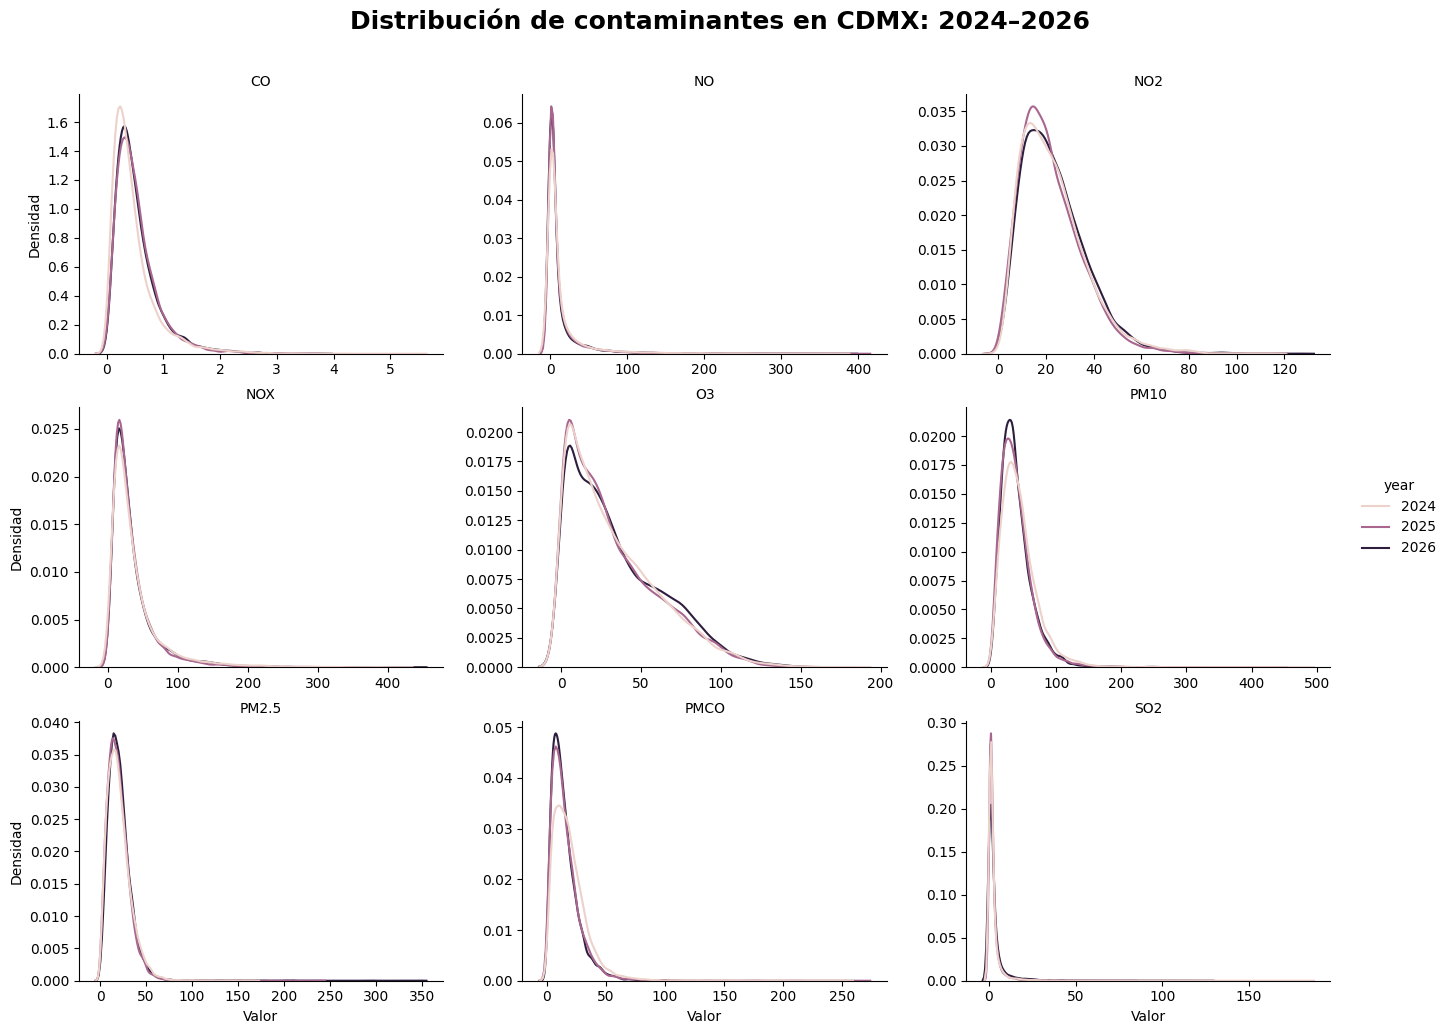

In [ ]:
g = sns.displot(
    data=df_plot,
    x="valor",
    hue="year",
    col="id_parameter",
    col_wrap=3,
    kind="kde",
    common_norm=False,
    fill=False,
    facet_kws={
        "sharex": False,
        "sharey": False
    },
    height=3.5,
    aspect=1.3
)

g.set_axis_labels("Valor", "Densidad")
g.set_titles("{col_name}")

g.fig.subplots_adjust(top=0.90)

g.fig.suptitle(
    "Distribución de contaminantes en CDMX: 2024–2026",
    fontsize=18,
    fontweight="bold"
)

plt.show()

Esta gráfica muestra la distribución de las mediciones de cada contaminante durante 2024, 2025 y 2026. Las curvas KDE permiten observar dónde se concentran principalmente los valores y comparar si la forma de la distribución cambia entre años. Cada contaminante se presenta por separado porque sus escalas de medición pueden ser diferentes.

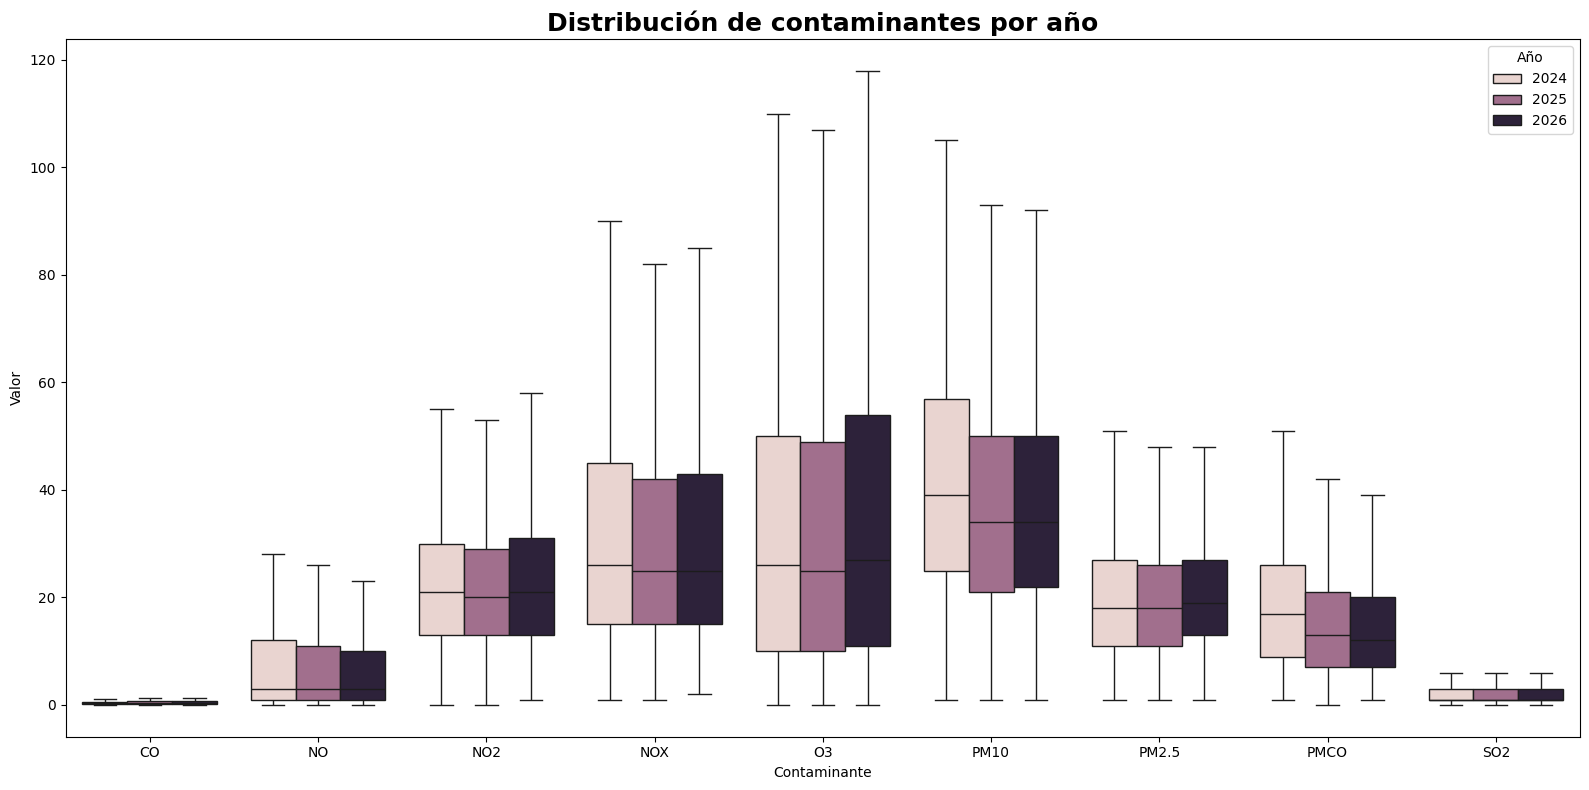

In [ ]:
plt.figure(figsize=(16, 8))

sns.boxplot(
    data=df_plot,
    x="id_parameter",
    y="valor",
    hue="year",
    showfliers=False
)

plt.title(
    "Distribución de contaminantes por año",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Contaminante")
plt.ylabel("Valor")

plt.legend(title="Año")

plt.tight_layout()
plt.show()

El boxplot permite comparar la mediana y la dispersión de las mediciones entre contaminantes y años. La línea central de cada caja representa la mediana, mientras que el tamaño de la caja muestra qué tan dispersa está la parte central de los datos. Los valores extremos se ocultan únicamente en la visualización para facilitar la comparación.

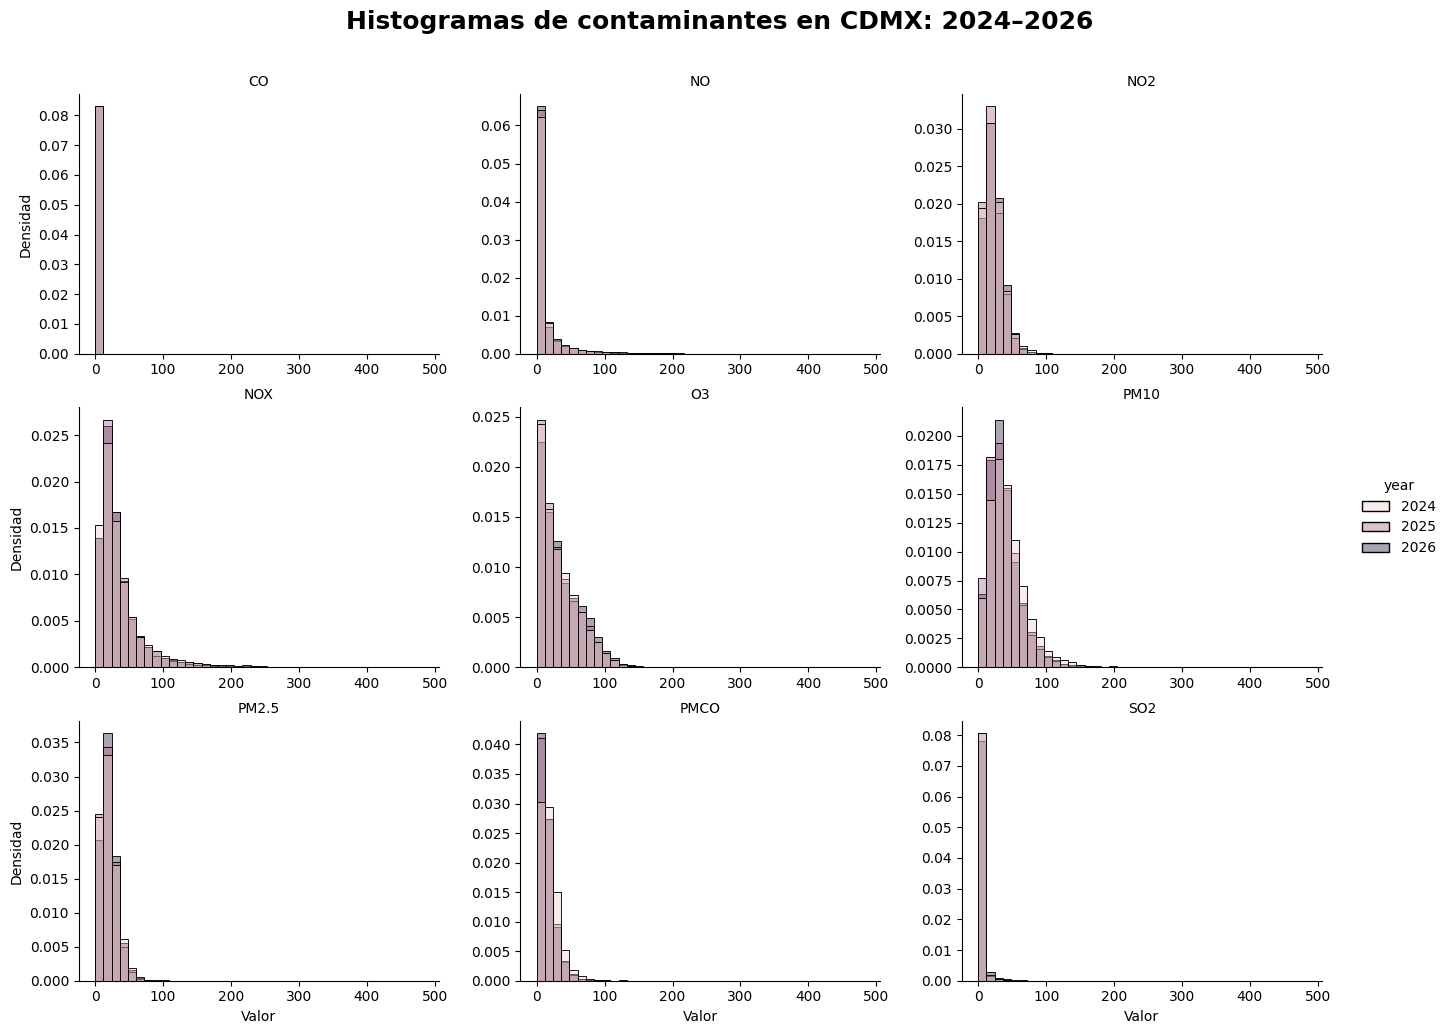

In [ ]:
# histogramas para observar la distribución real de las mediciones de cada contaminante.
g = sns.displot(
    data=df_plot,
    x="valor",
    hue="year",
    col="id_parameter",
    col_wrap=3,

    kind="hist",

    # Número de intervalos del histograma
    bins=40,

    stat="density",
    common_norm=False,
    alpha=0.4,

    # Cada contaminante conserva su propia escala
    facet_kws={
        "sharex": False,
        "sharey": False
    },

    height=3.5,
    aspect=1.3
)

g.set_axis_labels("Valor", "Densidad")
g.set_titles("{col_name}")
g.fig.subplots_adjust(top=0.90)

g.fig.suptitle(
    "Histogramas de contaminantes en CDMX: 2024–2026",
    fontsize=18,
    fontweight="bold"
)

plt.show()

In [ ]:
# comparar media y mediana en una misma gráfica.
tendencia_plot = tendencia_central.melt(
    id_vars=["year", "id_parameter"],
    value_vars=["media", "mediana"],
    var_name="medida",
    value_name="valor"
)

tendencia_plot.head()

,year,id_parameter,medida,valor
0,2024,CO,media,0.472702
1,2024,NO,media,13.756513
2,2024,NO2,media,23.382838
3,2024,NOX,media,37.215829
4,2024,O3,media,33.057411


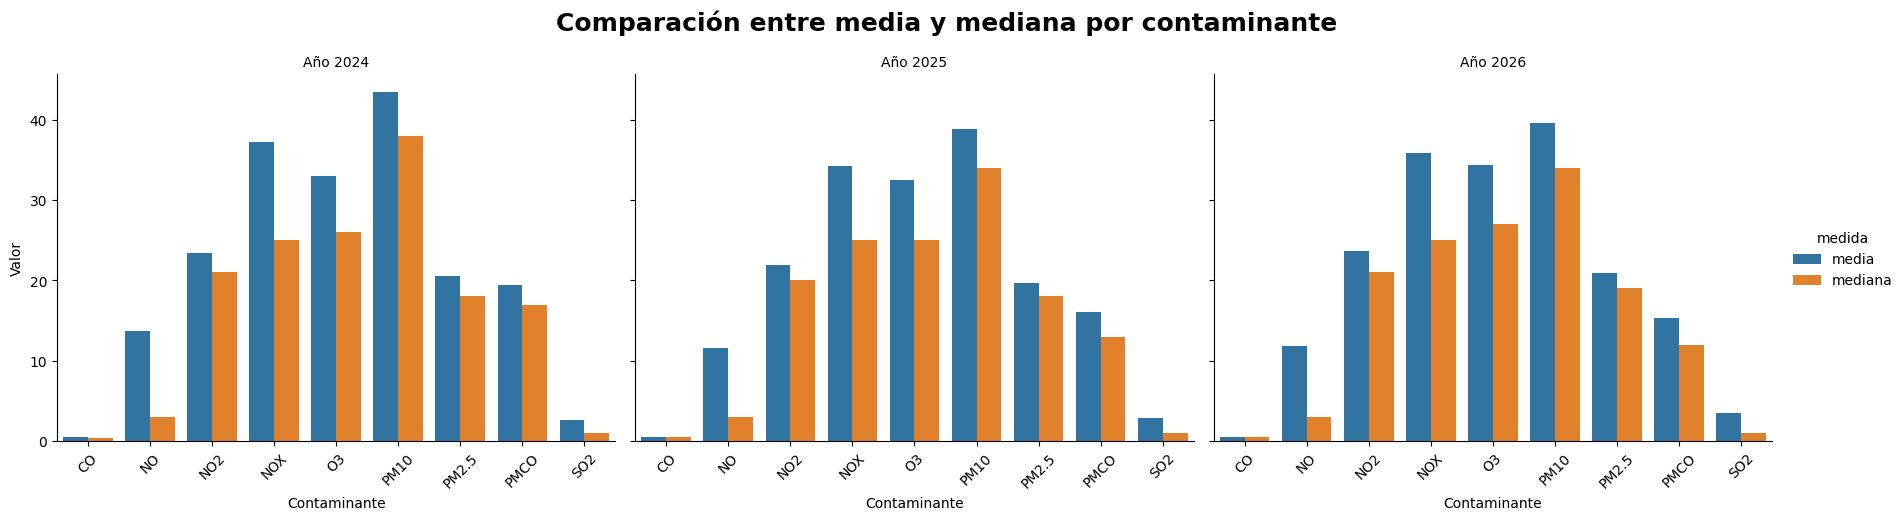

In [ ]:
# Crear una gráfica por año
g = sns.catplot(
    data=tendencia_plot,
    x="id_parameter",
    y="valor",
    hue="medida",
    col="year",

    kind="bar",

    height=5,
    aspect=1.2
)

g.set_axis_labels("Contaminante", "Valor")
g.set_titles("Año {col_name}")

for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)

g.fig.subplots_adjust(top=0.85)

g.fig.suptitle(
    "Comparación entre media y mediana por contaminante",
    fontsize=18,
    fontweight="bold"
)

plt.show()

In [ ]:
# Concentración promedio de cada contaminante por año y por mes.
promedio_mensual = (
    df_clean
    .groupby(
        ["year", "month", "id_parameter"]
    )["valor"]
    .mean()
    .reset_index()
)

promedio_mensual.head()

,year,month,id_parameter,valor
0,2024,1.0,CO,0.633837
1,2024,1.0,NO,25.389164
2,2024,1.0,NO2,28.288116
3,2024,1.0,NOX,53.649923
4,2024,1.0,O3,23.693052


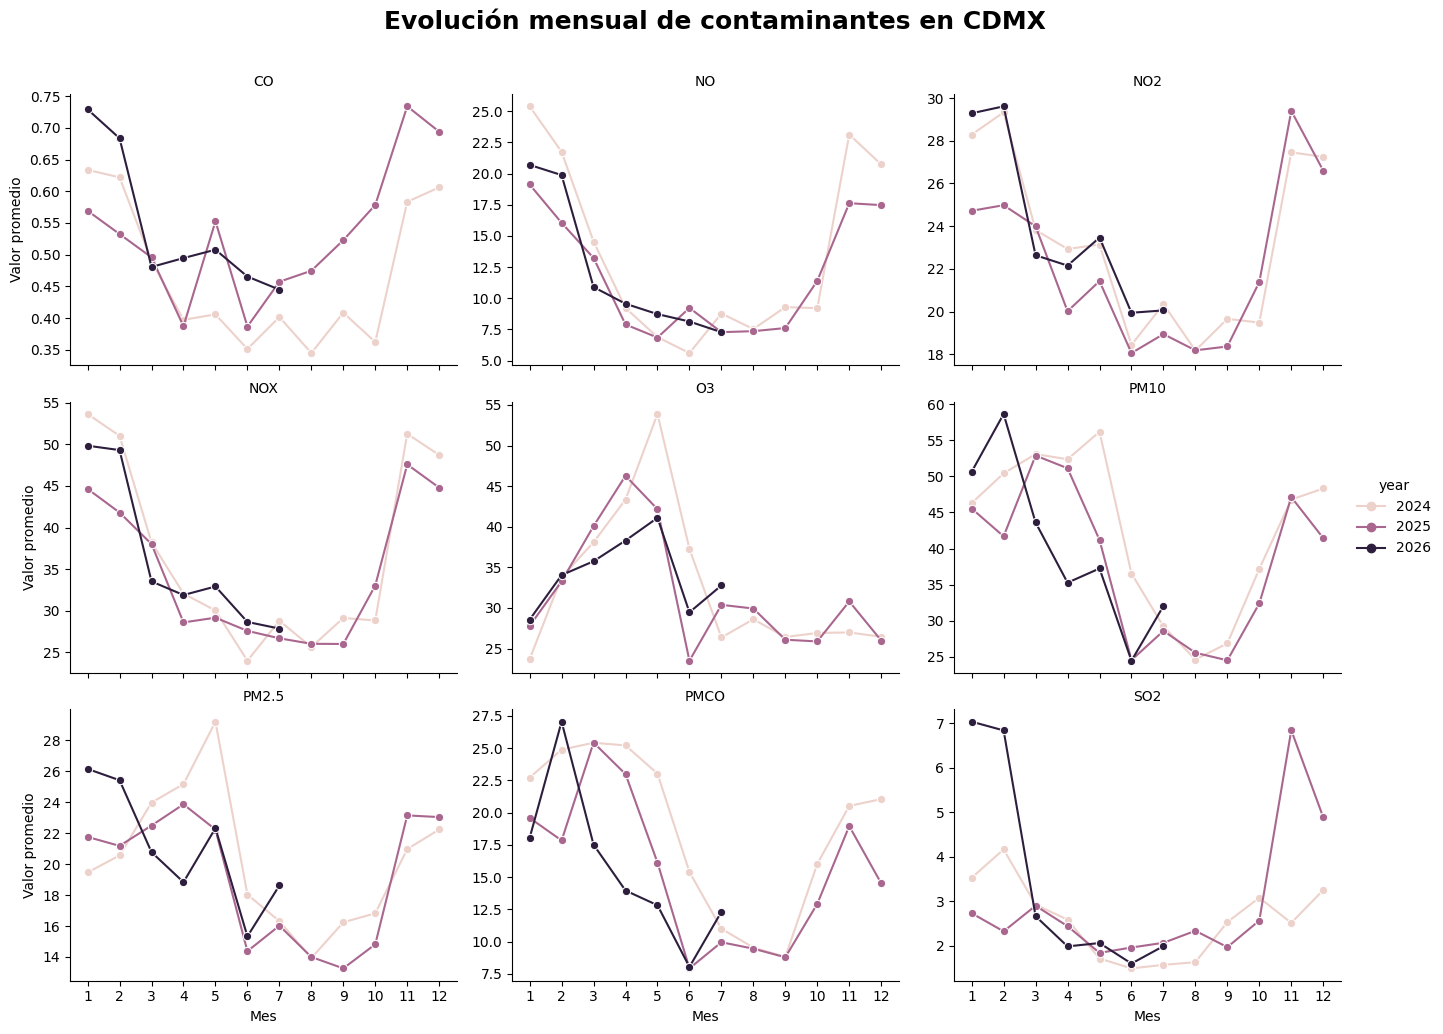

In [ ]:
# Crear una gráfica de líneas para cada contaminante
g = sns.relplot(
    data=promedio_mensual,
    x="month",
    y="valor",
    hue="year",
    col="id_parameter",
    col_wrap=3,
    kind="line",
    marker="o",

    facet_kws={
        "sharex": True,
        "sharey": False
    },

    height=3.5,
    aspect=1.3
)

g.set_axis_labels(
    "Mes",
    "Valor promedio"
)

g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.set_xticks(range(1, 13))

g.fig.subplots_adjust(top=0.90)

g.fig.suptitle(
    "Evolución mensual de contaminantes en CDMX",
    fontsize=18,
    fontweight="bold"
)

plt.show()

Esta gráfica presenta la evolución mensual del valor promedio de cada contaminante. Permite identificar meses con concentraciones relativamente mayores o menores y comparar el comportamiento observado durante 2024, 2025 y 2026. Para 2026 deben interpretarse únicamente los meses disponibles en el archivo, ya que el año puede no estar completo.

In [ ]:
# Resumen final del dataset después del proceso de limpieza
print("Dimensiones finales:", df_clean.shape)
print("\nValores nulos:")
print(df_clean.isnull().sum())

print("\nAños analizados:")
print(df_clean["year"].value_counts().sort_index())

print("\nContaminantes analizados:")
print(df_clean["id_parameter"].unique())

Dimensiones finales: (3591387, 9)

Valores nulos:
date            0
id_station      0
id_parameter    0
valor           0
unit            0
year            0
month           0
day             0
hour            0
dtype: int64

Años analizados:
year
2024    1347430
2025    1425789
2026     818168
Name: count, dtype: int64

Contaminantes analizados:
['CO' 'NO' 'NO2' 'NOX' 'O3' 'PM10' 'PM2.5' 'PMCO' 'SO2']
